## 1. Importar librerías

In [1]:
import sys
import os
import numpy as np
import random
import matplotlib.pyplot as plt
from glob import glob

# Añadir src a path para importar utils
# sys.path.append(os.path.join(os.getcwd(), '../../src'))
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(PROJECT_ROOT)

from src.utils import (
    renombrar_imagenes_cara,
    renombrar_imagenes_sincara,
    renombrar_predicciones,
    list_images,
    analyze_sizes,
    mean_color,
    show_random_by_class,
    symmetry_score,
    find_outliers,
    TRAIN_PATH,
    TEST_PATH
)

import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

# Parámetros globales


# DATASET

## 2. Renombrar las imágenes

In [ ]:
# # Ejecutamos función desde los directorios donde tenemos las imágenes
cara_renombrar = 'C:/Users/urkow/Documents/Documentos_Clase/Caraduras_ML/data/train/cara'
sincara_renombrar = 'C:/Users/urkow/Documents/Documentos_Clase/Caraduras_ML/data/train/sin-cara'
renombrar_imagenes_cara(cara_renombrar)
renombrar_imagenes_sincara(sincara_renombrar)

cara_renombrar = 'C:/Users/urkow/Documents/Documentos_Clase/Caraduras_ML/data/test/cara'
sincara_renombrar = 'C:/Users/urkow/Documents/Documentos_Clase/Caraduras_ML/data/test/sin-cara'
renombrar_imagenes_cara(cara_renombrar)
renombrar_imagenes_sincara(sincara_renombrar)

prediciones = 'C:/Users/urkow/Documents/Documentos_Clase/Caraduras_ML/data/predictions'
renombrar_predicciones(prediciones)

cara_001.jpg → cara_009.jpg
cara_002.jpg → cara_024.jpg
cara_003.jpg → cara_033.jpg
cara_004.jpg → cara_034.jpg
cara_005.jpg → cara_035.jpg
cara_006.jpg → cara_036.jpg
cara_007.jpg → cara_037.jpg
cara_008.jpg → cara_038.jpg
cara_009.png → cara_010.png
cara_010.jpg → cara_039.jpg
cara_011.jpg → cara_040.jpg
cara_012.jpg → cara_041.jpg
cara_013.jpg → cara_042.jpg
cara_014.jpg → cara_043.jpg
cara_015.jpg → cara_044.jpg
cara_016.jpg → cara_045.jpg
cara_017.jpg → cara_046.jpg
cara_018.jpg → cara_047.jpg
cara_019.jpg → cara_048.jpg
cara_020.jpg → cara_049.jpg
cara_021.jpg → cara_050.jpg
cara_022.jpg → cara_051.jpg
cara_023.jpg → cara_052.jpg
cara_024.jpeg → cara_025.jpeg
cara_025.jpg → cara_053.jpg
cara_026.jpg → cara_054.jpg
cara_027.jpg → cara_055.jpg
cara_028.jpg → cara_056.jpg
cara_029.jpg → cara_057.jpg
cara_030.jpg → cara_058.jpg
cara_031.jpg → cara_059.jpg
cara_032.jpg → cara_060.jpg
cara_033.jpeg → cara_062.jpeg
cara_034.jpeg → cara_063.jpeg
cara_035.jpeg → cara_064.jpeg
cara_036.jpe

# Image EDA

Vamos a ojear ciertas características de las imágenes, como tamaños, color, muestras, simetría, outliers

#### Distribución de tamaños y resoluciones

In [2]:
train_paths = list_images(TRAIN_PATH)
test_paths = list_images(TEST_PATH)

sizes_train = analyze_sizes(train_paths)
print('Train images:', len(train_paths))
print('Unique sizes (sample):', np.unique(sizes_train, axis=0)[:10])

Train images: 878
Unique sizes (sample): [[ 19 400]
 [ 46  46]
 [ 46  57]
 [ 48  46]
 [ 50  50]
 [ 69  46]
 [ 82  46]
 [101 400]
 [129 389]
 [150 335]]


#### Histograma de anchos y altos

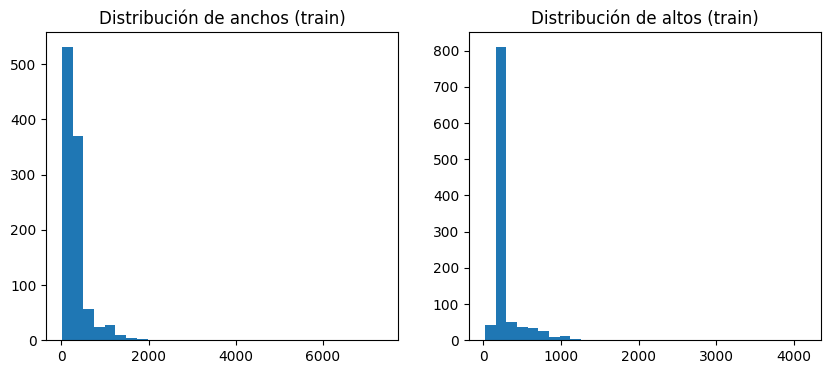

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(sizes_train[:,0], bins=30)
plt.title('Distribución de anchos (train)')
plt.subplot(1,2,2)
plt.hist(sizes_train[:,1], bins=30)
plt.title('Distribución de altos (train)');

In [ ]:
from scipy import stats

media = sizes_train.mean(axis=0)
moda_altura = stats.mode(sizes_train[:,0], keepdims=True).mode[0]
moda_anchura = stats.mode(sizes_train[:,1], keepdims=True).mode[0]

print(media)
print(moda_altura, moda_anchura)

[340.7631068  287.56019417]
275 183


#### Color medio por imagen (RGB)

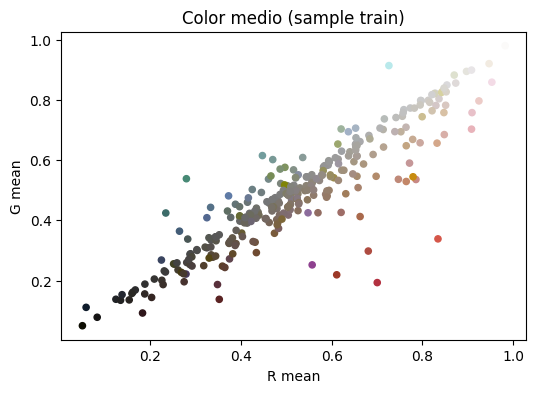

In [ ]:
# Calcular medias para una muestra (por rendimiento)
sample = random.sample(train_paths, min(300, len(train_paths)))
means = np.array([mean_color(p) for p in sample])
plt.figure(figsize=(6,4))
plt.scatter(means[:,0], means[:,1], c=means, s=20)
plt.xlabel('R mean'); plt.ylabel('G mean'); plt.title('Color medio (sample train)');

#### Visualización aleatoria por clase

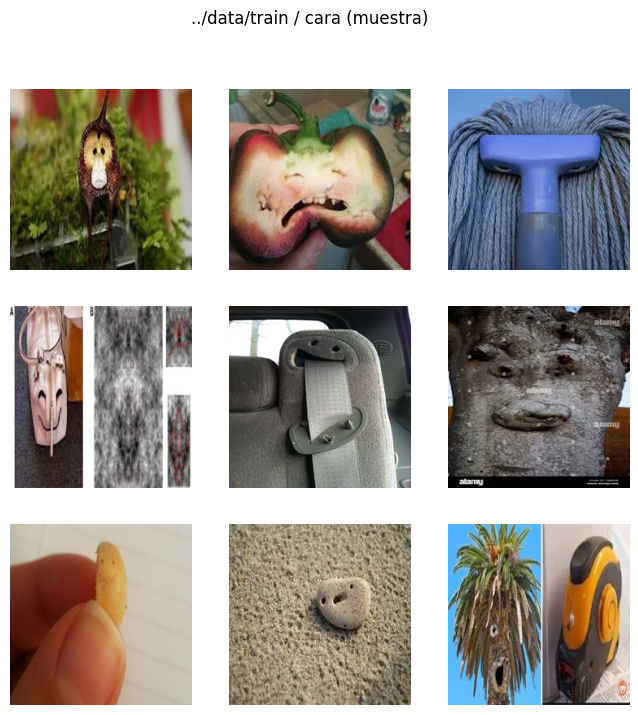

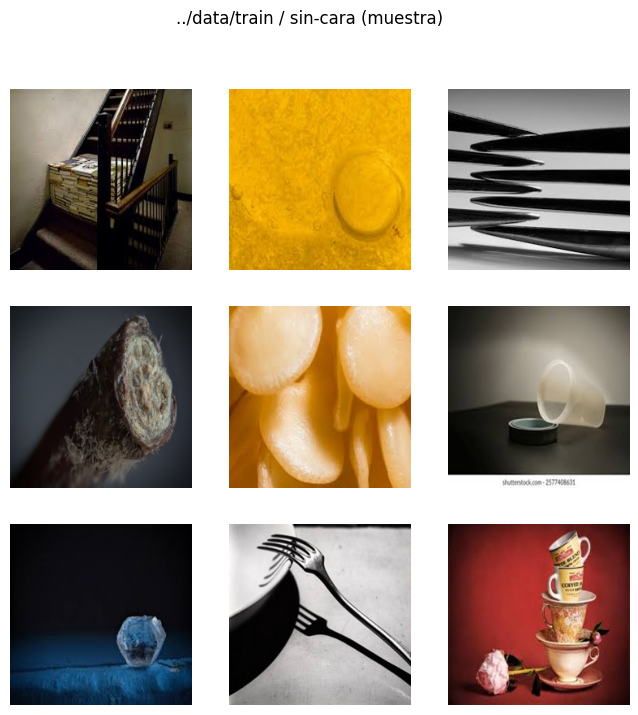

In [ ]:
show_random_by_class(TRAIN_PATH, 'cara', n=9);
show_random_by_class(TRAIN_PATH, 'sin-cara', n=9);

#### Simetría horizontal (medida simple)

Simetría media cara: 0.41726994654122734 sin_cara: 0.3539184213194707


C:\Users\urkow\AppData\Local\Temp\ipykernel_18260\2441217297.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([sym_face, sym_noface], labels=['cara','sin_cara'])


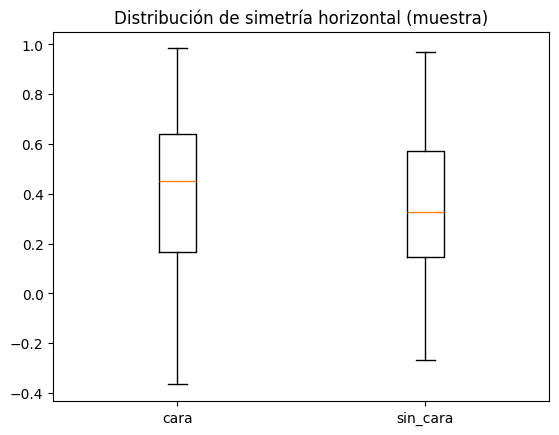

In [ ]:
# Calcular simetría para una muestra por clase
sample_face = random.sample(glob(TRAIN_PATH + '/cara/*'), min(200, len(glob(TRAIN_PATH + '/cara/*'))))
sample_noface = random.sample(glob(TRAIN_PATH + '/sin-cara/*'), min(200, len(glob(TRAIN_PATH + '/sin-cara/*'))))

sym_face = np.array([symmetry_score(p) for p in sample_face])
sym_noface = np.array([symmetry_score(p) for p in sample_noface])

print('Simetría media cara:', sym_face.mean(), 'sin_cara:', sym_noface.mean())
plt.boxplot([sym_face, sym_noface], labels=['cara','sin_cara'])
plt.title('Distribución de simetría horizontal (muestra)');

#### Outliers por tamaño o fallo de lectura

In [ ]:
outliers = find_outliers(train_paths)
print('Outliers detectados (ejemplos):', outliers[:10]);

Outliers detectados (ejemplos): [('../data/train\\sin-cara\\sin_cara035.png', 'too_small', (24, 24)), ('../data/train\\sin-cara\\sin_cara040.png', 'too_small', (25, 21)), ('../data/train\\sin-cara\\sin_cara065.jpeg', 'too_small', (82, 46)), ('../data/train\\sin-cara\\sin_cara066.jpeg', 'too_small', (69, 46)), ('../data/train\\sin-cara\\sin_cara067.jpeg', 'too_small', (46, 57)), ('../data/train\\sin-cara\\sin_cara072.jpeg', 'too_small', (48, 46)), ('../data/train\\sin-cara\\sin_cara073.jpeg', 'too_small', (46, 46)), ('../data/train\\sin-cara\\sin_cara619.jpeg', 'too_small', (19, 400)), ('../data/train\\sin-cara\\sin_cara620.jpeg', 'too_small', (69, 46))]
